In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
from pathlib import Path

import torchshow as ts

from mmpr.data.data_reader import FramesDataReader


In [6]:
REPO_ROOT = Path("/home/docker_mmpr/multimodal-place-recognition")

DATA_DIR = REPO_ROOT / "data" / "2025-03-26-mmpr-datasets" / "mmpr_dataset_1" / "mav0"
assert DATA_DIR.exists(), f"Data directory {DATA_DIR} does not exist."

In [8]:
reader = FramesDataReader(
    DATA_DIR,
    frames_csv=DATA_DIR / "frames.csv",
    pointcloud_quantization_size=0.05,
    image_transform=None,
    sensors_to_load=None,
)


In [ ]:
sample = reader[10]

/usr/local/lib/python3.10/dist-packages/albumentations/pytorch/transforms.py:86: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  return torch.from_numpy(img.transpose(2, 0, 1))


In [11]:
sample.keys()

dict_keys(['pose', 'pose_timestamp', 'timestamp_lidar_joined', 'pointcloud_lidar_joined_coords', 'pointcloud_lidar_joined_feats', 'timestamp_lidar0', 'pointcloud_lidar0_coords', 'pointcloud_lidar0_feats', 'timestamp_lidar1', 'pointcloud_lidar1_coords', 'pointcloud_lidar1_feats', 'timestamp_cam0', 'image_cam0', 'timestamp_cam1', 'image_cam1', 'timestamp_cam2', 'image_cam2', 'timestamp_cam3', 'image_cam3', 'depth_timestamp', 'depth'])

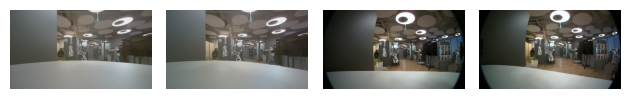

In [18]:
image_keys = [k for k in sample.keys() if "image" in k]
images = [sample[k] for k in image_keys]
ts.show(images)


In [22]:
pointcloud_coords_keys = [k for k in sample.keys() if "pointcloud" in k and "coords" in k]
pointcloud_coords = [sample[k] for k in pointcloud_coords_keys]

len(pointcloud_coords), pointcloud_coords[0].shape, pointcloud_coords[1].shape, pointcloud_coords[2].shape

(3, torch.Size([39936, 3]), torch.Size([19872, 3]), torch.Size([20064, 3]))

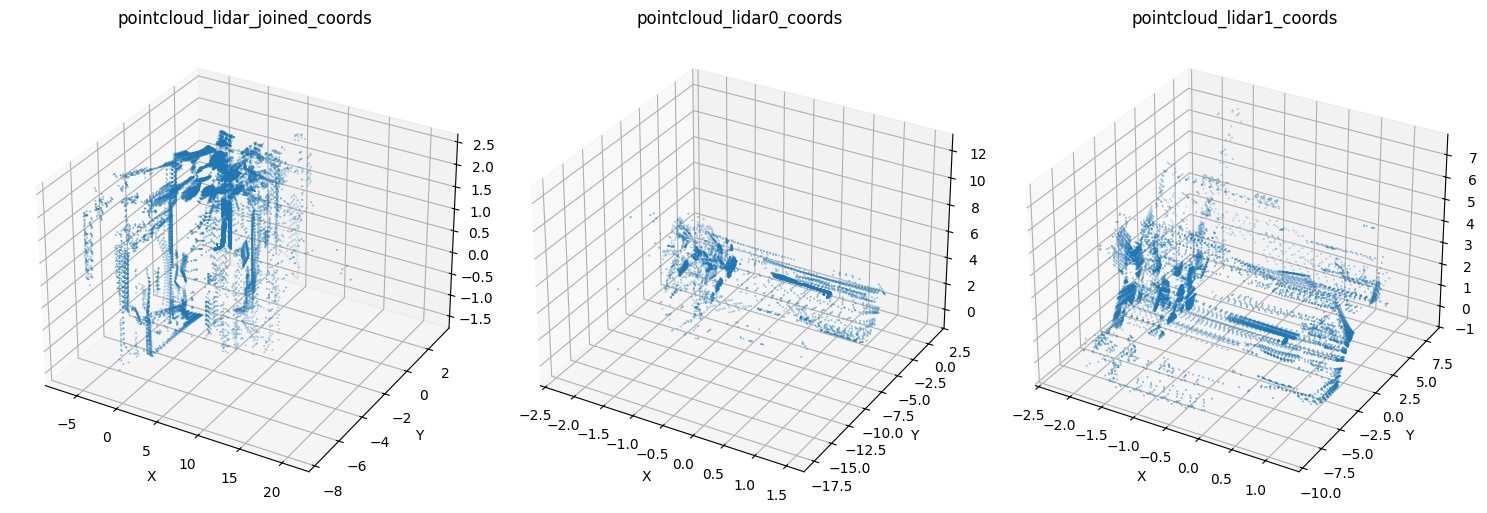

In [23]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 5))
for i, coords in enumerate(pointcloud_coords):
    ax = fig.add_subplot(1, len(pointcloud_coords), i + 1, projection='3d')
    xyz = coords.cpu().numpy() if hasattr(coords, "cpu") else coords.numpy()
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=0.1)
    ax.set_title(pointcloud_coords_keys[i])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
plt.tight_layout()
plt.show()
